In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate reproducible nonlinear data
np.random.seed(42)

X = np.linspace(0, 10, 40).reshape(-1, 1)

#np.random.normal(0,5,40) is to genearte random noise
#and add realistic variation to the output data
#np.random.normal(mean,Standard_deviation,number_of_values)
y=2 + 0.5 * X[:,0] ** 2 + np.random.normal(0,5,40)

#Divide the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

degrees=[1,2,3,4,5,10]

#include_bias=False - is to tell Polynomial not to create
#an additional constant column containing only  1s

for degree in degrees:
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)

    train_prediction=model.predict(X_train)
    test_prediction=model.predict(X_test)

    train_mse=mean_squared_error(y_train,train_prediction)
    test_mse=mean_squared_error(y_test,test_prediction)

    print(f"Polynomial degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    print(f"Testing MSE: {test_mse:.2f}")
    print()

Polynomial degree: 1
Training MSE: 44.19
Testing MSE: 41.82

Polynomial degree: 2
Training MSE: 20.07
Testing MSE: 21.48

Polynomial degree: 3
Training MSE: 19.41
Testing MSE: 19.57

Polynomial degree: 4
Training MSE: 18.90
Testing MSE: 17.90

Polynomial degree: 5
Training MSE: 17.34
Testing MSE: 19.89

Polynomial degree: 10
Training MSE: 18.94
Testing MSE: 15.78



***plotting the fitted Model***

<function matplotlib.pyplot.show(close=None, block=None)>

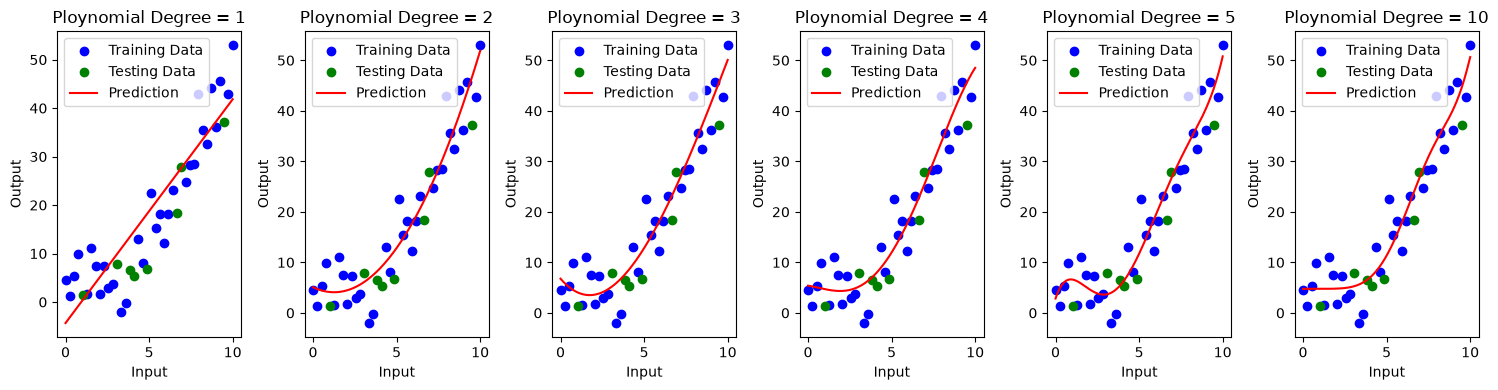

In [2]:
X_plot=np.linspace(0,10,200).reshape(-1,1)

plt.figure(figsize=(15,4))

for index,degree in enumerate(degrees):
    model=make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)
    y_plot=model.predict(X_plot)

    plt.subplot(1,len(degrees),index + 1)
    plt.scatter(X_train,y_train,color="blue",label="Training Data")
    plt.scatter(X_test,y_test,color="green",label="Testing Data")
    plt.plot(X_plot,y_plot,color="red",label="Prediction")

    plt.title(f"Ploynomial Degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.legend()

plt.tight_layout()
plt.show

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np


for degree in range(1,11):
    model=make_pipeline(
    PolynomialFeatures(degree=degree,include_bias=False),
    LinearRegression()
    )

    scores=cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
        #scikit learn returns the negative value of the mean Squared error(MSE) so that higher(less negative values represent better model performance)
    )

    mean_mse=-scores.mean()
    print(f"Degree {degree}: cv MSE = {mean_mse: .2f}")

Degree 1: cv MSE =  110.69
Degree 2: cv MSE =  44.22
Degree 3: cv MSE =  71.23
Degree 4: cv MSE =  82.46
Degree 5: cv MSE =  1346.32
Degree 6: cv MSE =  7930.95
Degree 7: cv MSE =  20375.98
Degree 8: cv MSE =  31567.34
Degree 9: cv MSE =  55109.01
Degree 10: cv MSE =  67544.63


In [4]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X=pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,0],
    "useful_feature":[10,20,30,40,50]
})

selector=VarianceThreshold(threshold=0.0)
X_selected=selector.fit_transform(X)

selected_columns=X.columns[selector.get_support()]

print("selected features: ",list(selected_columns))

selected features:  ['useful_feature']


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6],
    "attendance": [50, 55, 65, 70, 80, 90],
    "previous_marks": [35, 40, 50, 55, 65, 75],
    "final_marks": [38, 45, 52, 60, 70, 82]
})

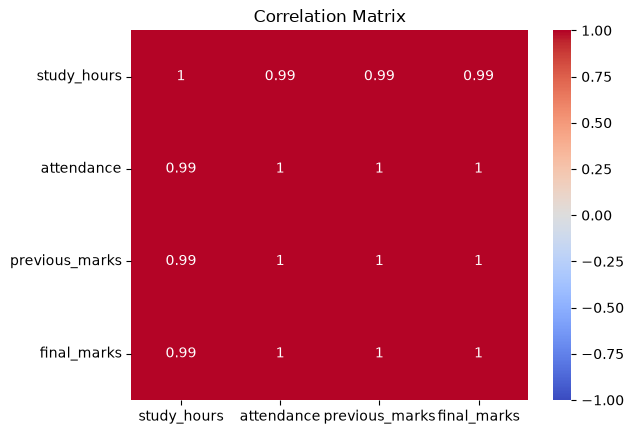

In [6]:
correlation_matrix=data.corr(numeric_only=True)

#print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
        vmin=-1,
    vmax=1

)

plt.title("Correlation Matrix")
plt.show()

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6],
    "attendance": [5, 6, 7, 10, 80, 90],
    "previous_marks": [35, 40, 50, 55, 65, 75],
    "final_marks": [38, 45, 52, 60, 70, 82]
})

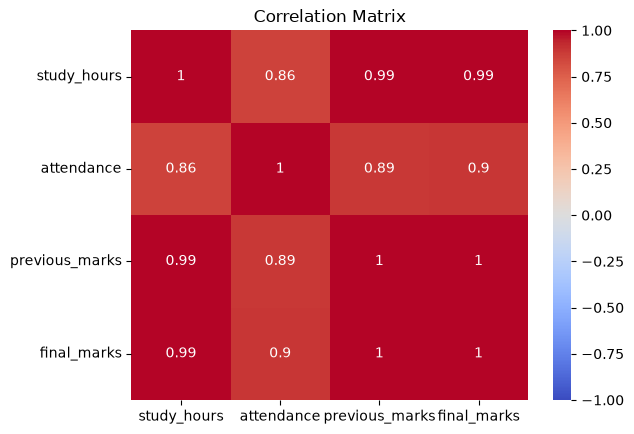

In [8]:
correlation_matrix=data.corr(numeric_only=True)

#print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
        vmin=-1,
    vmax=1

)

plt.title("Correlation Matrix")
plt.show()

Chi-Square test

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

data=load_breast_cancer()
X=data.data
y=data.target

In [10]:
print("Number of Features: ",X.shape[1])


Number of Features:  30


In [11]:
#chi-square requires non-negative feature values
X_non_negative=MinMaxScaler().fit_transform(X)

selector=SelectKBest(score_func=chi2,k=5)
X_selected=selector.fit_transform(X_non_negative,y)

selected_features=data.feature_names[selector.get_support()]

print("selected Features : ")
print(selected_features)

selected Features : 
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


***for iris dataset***

In [12]:
from sklearn.datasets import load_iris

In [13]:
iris=load_iris()
X,y=iris.data,iris.target

In [14]:
X.shape

(150, 4)

In [15]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [16]:
X_select=SelectKBest(chi2,k=3).fit_transform(X,y)
X_select



array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

In [17]:
# f_classif applies the ANOVA F-test to each feature

from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,f_classif

data=load_iris()
X=data.data
y=data.target

selector=SelectKBest(score_func=f_classif,k=2)
X_selected=selector.fit_transform(X,y)

import numpy as np

selected_features=np.array(data.feature_names)[selector.get_support()]

print("Selected features : ",selected_features)

Selected features :  ['petal length (cm)' 'petal width (cm)']
